In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df

,Id,Title,Body,Tags
0,5131316,pdf download option should appear,<p>I need some code to download a pdf file.</p...,php javascript download
1,1547059,com iplanet ias JAR,<p>I've been struggling with this for past cou...,java junit glassfish ibatis sunone
2,3542388,How to get the Crash Log from Apple?,"<p>We developed an app, and it works perfectly...",ios crash apple emulator appstore-approval
3,4065519,Android Center Buttons,<p>How do I center a button and make it so it ...,android
4,2997091,Parallelizing L2S Entity Retrieval,<p>Assuming a typical domain entity approach w...,sql sql-server linq-to-sql domain-driven-design
...,...,...,...,...
9995,3307872,Snapping to specific grid positions,<p>I have a grid system laid out that lets me ...,xna
9996,86781,How to sign all the msi file which are under f...,<p>I am using signtool to sign my msi.</p>\n\n...,powershell batch-file powershell-v2.0 code-sig...
9997,537060,Cardinality of an infinite separable connected...,<p>How to prove:</p>\n\n<p>Cardinality of an i...,general-topology cardinals
9998,2907651,What if app sleeping or dead before NSURLConne...,"<p>What will happen if an app is either dead, ...",nsurlconnection nsurlconnectiondelegate


In [5]:

d={}
def diff_tags(x):
  l=list(str(x).split())
  for i in l:
    if i in d:
      d[i]+=1;
    else:
      d[i]=1
df['dummy']=df['Tags'].apply(diff_tags)

In [6]:
df_dummy=pd.DataFrame()
df_dummy['Tags']=d.keys()
df_dummy['Count']=d.values()
df_dummy.head()

,Tags,Count
0,php,700
1,javascript,626
2,download,14
3,java,702
4,junit,7


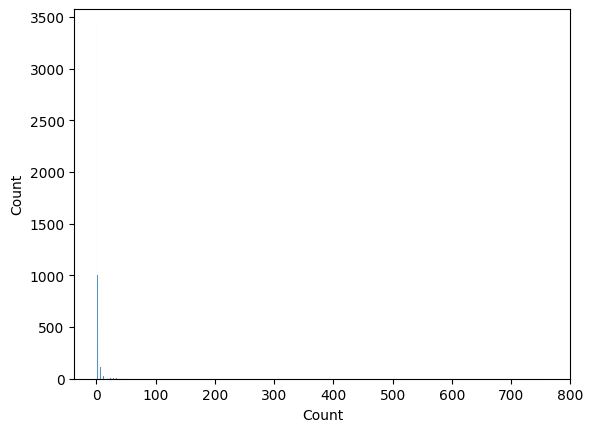

In [7]:
sns.histplot(df_dummy['Count'])
plt.show()

In [8]:
print(df_dummy['Count'].sum())

28754


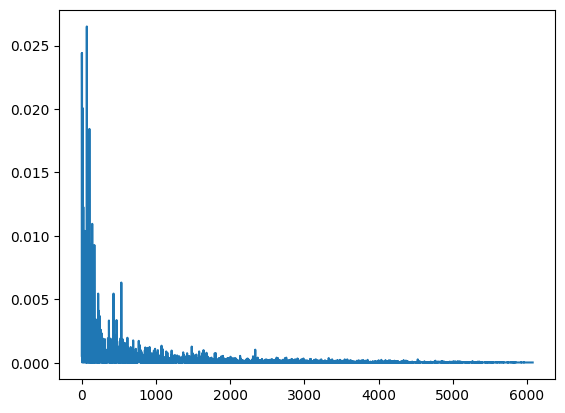

In [9]:
plt.plot(df_dummy['Count']/df_dummy['Count'].sum())
plt.show()

In [10]:
print(df_dummy['Tags'][df_dummy['Count'] >=10].shape)

(426,)


In [11]:
df_dummy=df_dummy[df_dummy['Count'] >=10]

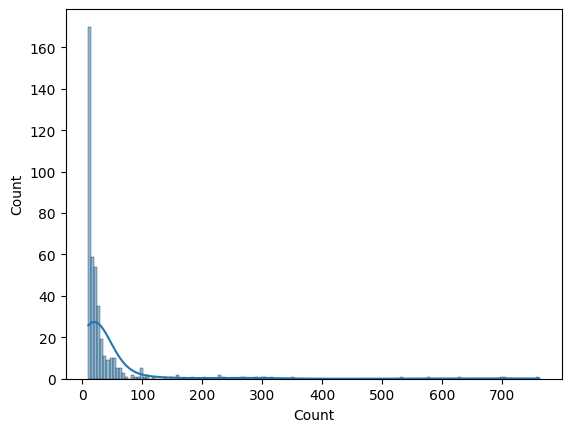

In [12]:
sns.histplot(df_dummy['Count'],kde=True)
plt.show()

In [13]:
df

,Id,Title,Body,Tags,dummy
0,5131316,pdf download option should appear,<p>I need some code to download a pdf file.</p...,php javascript download,None
1,1547059,com iplanet ias JAR,<p>I've been struggling with this for past cou...,java junit glassfish ibatis sunone,None
2,3542388,How to get the Crash Log from Apple?,"<p>We developed an app, and it works perfectly...",ios crash apple emulator appstore-approval,None
3,4065519,Android Center Buttons,<p>How do I center a button and make it so it ...,android,None
4,2997091,Parallelizing L2S Entity Retrieval,<p>Assuming a typical domain entity approach w...,sql sql-server linq-to-sql domain-driven-design,None
...,...,...,...,...,...
9995,3307872,Snapping to specific grid positions,<p>I have a grid system laid out that lets me ...,xna,None
9996,86781,How to sign all the msi file which are under f...,<p>I am using signtool to sign my msi.</p>\n\n...,powershell batch-file powershell-v2.0 code-sig...,None
9997,537060,Cardinality of an infinite separable connected...,<p>How to prove:</p>\n\n<p>Cardinality of an i...,general-topology cardinals,None
9998,2907651,What if app sleeping or dead before NSURLConne...,"<p>What will happen if an app is either dead, ...",nsurlconnection nsurlconnectiondelegate,None


In [14]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [15]:
stop_words=stopwords.words('english')

In [16]:
len(stop_words)

198

In [17]:
df['Title']=df['Title']+" "+df['Title']

In [18]:
def removal_stopwords(x):
    l = str(x).split()
    l = [word for word in l if word.lower() not in stop_words]
    return " ".join(l)
df['Title'] = df['Title'].apply(removal_stopwords)

In [19]:
print(list(str(df['Body'][0]).split()))

['<p>I', 'need', 'some', 'code', 'to', 'download', 'a', 'pdf', 'file.</p>', '<p>what', 'i', 'mean', 'is', 'normaly', 'when', 'we', 'give', '</p>', '<p>like', 'this', 'href="./downloads/Intake', 'Sheet', 'rev', '4-1-10.pdf"</p>', '<p>that', 'will', 'open', 'the', 'pdf', 'in', 'the', 'same', 'window,', 'i', 'dont', 'want', 'this', ',', 'i', 'need', 'that', 'to', 'be', 'downloaded', ',', 'means', 'need', 'the', 'download', 'window', 'to', 'appear.</p>', "<p>i'm", 'using', 'php', 'to', 'develop', 'my', 'website.</p>', '<p>Please', 'give', 'me', 'some', 'idea.</p>', '<p>Thanks</p>']


In [20]:
import re
def remove_html_tags(text):
    clean = re.sub(r'<.*?>', '', str(text))
    return clean
df['Body'] = df['Body'].apply(remove_html_tags)

In [21]:
import re
def remove_html_tags(text):
    clean = re.sub(r'<.*?>|\n', ' ', str(text))
    return clean
df['Body'] = df['Body'].apply(remove_html_tags)

In [22]:
df['Body']=df['Body'].apply(removal_stopwords)

In [23]:
df

,Id,Title,Body,Tags,dummy
0,5131316,pdf download option appear pdf download option...,need code download pdf file. mean normaly give...,php javascript download,None
1,1547059,com iplanet ias JAR com iplanet ias JAR,struggling past couple days. trying test DAO o...,java junit glassfish ibatis sunone,None
2,3542388,get Crash Log Apple? get Crash Log Apple?,"developed app, works perfectly several differe...",ios crash apple emulator appstore-approval,None
3,4065519,Android Center Buttons Android Center Buttons,center button make 10px side. Basicly 100% wid...,android,None
4,2997091,Parallelizing L2S Entity Retrieval Parallelizi...,Assuming typical domain entity approach SQL Se...,sql sql-server linq-to-sql domain-driven-design,None
...,...,...,...,...,...
9995,3307872,Snapping specific grid positions Snapping spec...,"grid system laid lets snap objects grid, works...",xna,None
9996,86781,sign msi file folder? sign msi file folder?,using signtool sign msi. recursively search ms...,powershell batch-file powershell-v2.0 code-sig...,None
9997,537060,Cardinality infinite separable connected metri...,prove: Cardinality infinite separable connecte...,general-topology cardinals,None
9998,2907651,app sleeping dead NSURLConnection asynchronous...,"happen app either dead, dying, asleep, process...",nsurlconnection nsurlconnectiondelegate,None


In [24]:
df=df.drop(columns=['dummy','Id'])

In [25]:
df

,Title,Body,Tags
0,pdf download option appear pdf download option...,need code download pdf file. mean normaly give...,php javascript download
1,com iplanet ias JAR com iplanet ias JAR,struggling past couple days. trying test DAO o...,java junit glassfish ibatis sunone
2,get Crash Log Apple? get Crash Log Apple?,"developed app, works perfectly several differe...",ios crash apple emulator appstore-approval
3,Android Center Buttons Android Center Buttons,center button make 10px side. Basicly 100% wid...,android
4,Parallelizing L2S Entity Retrieval Parallelizi...,Assuming typical domain entity approach SQL Se...,sql sql-server linq-to-sql domain-driven-design
...,...,...,...
9995,Snapping specific grid positions Snapping spec...,"grid system laid lets snap objects grid, works...",xna
9996,sign msi file folder? sign msi file folder?,using signtool sign msi. recursively search ms...,powershell batch-file powershell-v2.0 code-sig...
9997,Cardinality infinite separable connected metri...,prove: Cardinality infinite separable connecte...,general-topology cardinals
9998,app sleeping dead NSURLConnection asynchronous...,"happen app either dead, dying, asleep, process...",nsurlconnection nsurlconnectiondelegate


In [26]:
df_dummy

,Tags,Count
0,php,700
1,javascript,626
2,download,14
3,java,702
8,ios,228
...,...,...
2738,wireless-networking,11
2756,ftp,12
2907,hash,10
2988,asp-classic,10


In [27]:
df

,Title,Body,Tags
0,pdf download option appear pdf download option...,need code download pdf file. mean normaly give...,php javascript download
1,com iplanet ias JAR com iplanet ias JAR,struggling past couple days. trying test DAO o...,java junit glassfish ibatis sunone
2,get Crash Log Apple? get Crash Log Apple?,"developed app, works perfectly several differe...",ios crash apple emulator appstore-approval
3,Android Center Buttons Android Center Buttons,center button make 10px side. Basicly 100% wid...,android
4,Parallelizing L2S Entity Retrieval Parallelizi...,Assuming typical domain entity approach SQL Se...,sql sql-server linq-to-sql domain-driven-design
...,...,...,...
9995,Snapping specific grid positions Snapping spec...,"grid system laid lets snap objects grid, works...",xna
9996,sign msi file folder? sign msi file folder?,using signtool sign msi. recursively search ms...,powershell batch-file powershell-v2.0 code-sig...
9997,Cardinality infinite separable connected metri...,prove: Cardinality infinite separable connecte...,general-topology cardinals
9998,app sleeping dead NSURLConnection asynchronous...,"happen app either dead, dying, asleep, process...",nsurlconnection nsurlconnectiondelegate


In [34]:
df['Tags']

,Tags
0,php javascript download
1,java junit glassfish ibatis sunone
2,ios crash apple emulator appstore-approval
3,android
4,sql sql-server linq-to-sql domain-driven-design
...,...
9995,xna
9996,powershell batch-file powershell-v2.0 code-sig...
9997,general-topology cardinals
9998,nsurlconnection nsurlconnectiondelegate


**Coversion Of OutPut Variables**

In [35]:
df['Tags'] = df['Tags'].apply(lambda x: x.split())

In [36]:
df['Tags']

,Tags
0,"[php, javascript, download]"
1,"[java, junit, glassfish, ibatis, sunone]"
2,"[ios, crash, apple, emulator, appstore-approval]"
3,[android]
4,"[sql, sql-server, linq-to-sql, domain-driven-d..."
...,...
9995,[xna]
9996,"[powershell, batch-file, powershell-v2.0, code..."
9997,"[general-topology, cardinals]"
9998,"[nsurlconnection, nsurlconnectiondelegate]"


In [37]:
from sklearn.preprocessing import MultiLabelBinarizer

mb = MultiLabelBinarizer()

encoded = mb.fit_transform(df['Tags'])

encoded_df = pd.DataFrame(encoded, columns=mb.classes_)

print(encoded_df.head())

   .htaccess  .net  .net-2.0  .net-3.5  .net-4.0  .net-4.5  .net-assembly  \
0          0     0         0         0         0         0              0   
1          0     0         0         0         0         0              0   
2          0     0         0         0         0         0              0   
3          0     0         0         0         0         0              0   
4          0     0         0         0         0         0              0   

   .net-micro-framework  .net-remoting  .nettiers  ...  zip  zipcode  zk  \
0                     0              0          0  ...    0        0   0   
1                     0              0          0  ...    0        0   0   
2                     0              0          0  ...    0        0   0   
3                     0              0          0  ...    0        0   0   
4                     0              0          0  ...    0        0   0   

   zoom  zope  zsh  zune  zurb-foundation  zxing  zywall  
0     0     0    0   

In [38]:
df=pd.concat([df,encoded_df],axis=1)

In [39]:
df=df.drop(columns='Tags',axis=1)

In [40]:
df

,Title,Body,.htaccess,.net,.net-2.0,.net-3.5,.net-4.0,.net-4.5,.net-assembly,.net-micro-framework,...,zip,zipcode,zk,zoom,zope,zsh,zune,zurb-foundation,zxing,zywall
0,pdf download option appear pdf download option...,need code download pdf file. mean normaly give...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,com iplanet ias JAR com iplanet ias JAR,struggling past couple days. trying test DAO o...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,get Crash Log Apple? get Crash Log Apple?,"developed app, works perfectly several differe...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Android Center Buttons Android Center Buttons,center button make 10px side. Basicly 100% wid...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Parallelizing L2S Entity Retrieval Parallelizi...,Assuming typical domain entity approach SQL Se...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Snapping specific grid positions Snapping spec...,"grid system laid lets snap objects grid, works...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,sign msi file folder? sign msi file folder?,using signtool sign msi. recursively search ms...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,Cardinality infinite separable connected metri...,prove: Cardinality infinite separable connecte...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,app sleeping dead NSURLConnection asynchronous...,"happen app either dead, dying, asleep, process...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [41]:
df.shape

(10000, 6080)

In [42]:
df['Conactinated']=df['Title']+" "+df['Body']

In [43]:
df

,Title,Body,.htaccess,.net,.net-2.0,.net-3.5,.net-4.0,.net-4.5,.net-assembly,.net-micro-framework,...,zipcode,zk,zoom,zope,zsh,zune,zurb-foundation,zxing,zywall,Conactinated
0,pdf download option appear pdf download option...,need code download pdf file. mean normaly give...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,pdf download option appear pdf download option...
1,com iplanet ias JAR com iplanet ias JAR,struggling past couple days. trying test DAO o...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,com iplanet ias JAR com iplanet ias JAR strugg...
2,get Crash Log Apple? get Crash Log Apple?,"developed app, works perfectly several differe...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,get Crash Log Apple? get Crash Log Apple? deve...
3,Android Center Buttons Android Center Buttons,center button make 10px side. Basicly 100% wid...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Android Center Buttons Android Center Buttons ...
4,Parallelizing L2S Entity Retrieval Parallelizi...,Assuming typical domain entity approach SQL Se...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Parallelizing L2S Entity Retrieval Parallelizi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Snapping specific grid positions Snapping spec...,"grid system laid lets snap objects grid, works...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Snapping specific grid positions Snapping spec...
9996,sign msi file folder? sign msi file folder?,using signtool sign msi. recursively search ms...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,sign msi file folder? sign msi file folder? us...
9997,Cardinality infinite separable connected metri...,prove: Cardinality infinite separable connecte...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Cardinality infinite separable connected metri...
9998,app sleeping dead NSURLConnection asynchronous...,"happen app either dead, dying, asleep, process...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,app sleeping dead NSURLConnection asynchronous...


In [47]:
df.columns

Index(['Title', 'Body', '.htaccess', '.net', '.net-2.0', '.net-3.5',
       '.net-4.0', '.net-4.5', '.net-assembly', '.net-micro-framework',
       ...
       'zipcode', 'zk', 'zoom', 'zope', 'zsh', 'zune', 'zurb-foundation',
       'zxing', 'zywall', 'Conactinated'],
      dtype='object', length=6081)

In [50]:
x=df.iloc[:,:2]

In [52]:
x['Conactinated']=df['Conactinated']

In [53]:
x

,Title,Body,Conactinated
0,pdf download option appear pdf download option...,need code download pdf file. mean normaly give...,pdf download option appear pdf download option...
1,com iplanet ias JAR com iplanet ias JAR,struggling past couple days. trying test DAO o...,com iplanet ias JAR com iplanet ias JAR strugg...
2,get Crash Log Apple? get Crash Log Apple?,"developed app, works perfectly several differe...",get Crash Log Apple? get Crash Log Apple? deve...
3,Android Center Buttons Android Center Buttons,center button make 10px side. Basicly 100% wid...,Android Center Buttons Android Center Buttons ...
4,Parallelizing L2S Entity Retrieval Parallelizi...,Assuming typical domain entity approach SQL Se...,Parallelizing L2S Entity Retrieval Parallelizi...
...,...,...,...
9995,Snapping specific grid positions Snapping spec...,"grid system laid lets snap objects grid, works...",Snapping specific grid positions Snapping spec...
9996,sign msi file folder? sign msi file folder?,using signtool sign msi. recursively search ms...,sign msi file folder? sign msi file folder? us...
9997,Cardinality infinite separable connected metri...,prove: Cardinality infinite separable connecte...,Cardinality infinite separable connected metri...
9998,app sleeping dead NSURLConnection asynchronous...,"happen app either dead, dying, asleep, process...",app sleeping dead NSURLConnection asynchronous...


In [54]:
y=df.drop(columns=['Title','Body','Conactinated'],axis=1)

In [56]:
y.shape

(10000, 6078)

In [65]:
from sklearn.model_selection import train_test_split

x_train_dummy,x_test,y_train_dummy,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train,x_cv,y_train,y_cv=train_test_split(x_train_dummy,y_train_dummy,test_size=0.1,random_state=42)

In [59]:
x_train

,Title,Body,Conactinated
4297,underlinks also underlinks also,good explaining english give go. Hope understa...,underlinks also underlinks also good explainin...
9090,get list video capture devices (web cameras) M...,need simple - list currently avaliable video c...,get list video capture devices (web cameras) M...
3113,Socket programming - broadcast net mask class ...,problem broadcasting data using class B netmas...,Socket programming - broadcast net mask class ...
6958,taking time call next activity pressing back b...,one suggest specifically single activity imple...,taking time call next activity pressing back b...
3901,VB MySql AddWithValue pass value successfully ...,"following VB code Dim cmd New MySqlCommand(""SE...",VB MySql AddWithValue pass value successfully ...
...,...,...,...
8871,Syncing library/project subversion respositori...,developing library alongside several projects ...,Syncing library/project subversion respositori...
9826,close mySQL connection in-between method calls...,question matter good idea/bad idea. using MySQ...,close mySQL connection in-between method calls...
5268,Understanding JavaScript Styling Understanding...,"following code, ""Secrets JavaScript Ninja,"" ""A...",Understanding JavaScript Styling Understanding...
9666,force certain applications use specific networ...,Let's say two active network connections let i...,force certain applications use specific networ...


In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import MultiLabelBinarizer

# Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', OneVsRestClassifier(LogisticRegression()))
])

# Parameters for tuning
params = {
    'tfidf__max_features': [1000, 3000, 5000, 10000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__min_df': [1, 2, 5]
}

# Random Search
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=params,
    n_iter=5,
    cv=3,
    verbose=2,
    n_jobs=-1
)

# Train
random_search.fit(x_train['Conactinated'], y_train)

# Best parameters
print(random_search.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 5 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 11 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 15 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 23 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 30 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 32 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 35 is present in all training exampl

{'tfidf__ngram_range': (1, 1), 'tfidf__min_df': 1, 'tfidf__max_features': 1000}


/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 6070 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 6074 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 6075 is present in all training examples.
  warnings.warn(


In [66]:
x_train

,Title,Body,Conactinated
4297,underlinks also underlinks also,good explaining english give go. Hope understa...,underlinks also underlinks also good explainin...
9090,get list video capture devices (web cameras) M...,need simple - list currently avaliable video c...,get list video capture devices (web cameras) M...
3113,Socket programming - broadcast net mask class ...,problem broadcasting data using class B netmas...,Socket programming - broadcast net mask class ...
6958,taking time call next activity pressing back b...,one suggest specifically single activity imple...,taking time call next activity pressing back b...
3901,VB MySql AddWithValue pass value successfully ...,"following VB code Dim cmd New MySqlCommand(""SE...",VB MySql AddWithValue pass value successfully ...
...,...,...,...
8871,Syncing library/project subversion respositori...,developing library alongside several projects ...,Syncing library/project subversion respositori...
9826,close mySQL connection in-between method calls...,question matter good idea/bad idea. using MySQ...,close mySQL connection in-between method calls...
5268,Understanding JavaScript Styling Understanding...,"following code, ""Secrets JavaScript Ninja,"" ""A...",Understanding JavaScript Styling Understanding...
9666,force certain applications use specific networ...,Let's say two active network connections let i...,force certain applications use specific networ...


In [69]:
x_train['all_text'] = (
    x_train['Title'].astype(str) + " " +
    x_train['Body'].astype(str) + " " +
    x_train['Conactinated'].astype(str)
)
tfidf = TfidfVectorizer(
    ngram_range=(1,1),
    min_df=1,
    max_features=1000,
    stop_words='english'
)

x_train_tfidf = tfidf.fit_transform(x_train['all_text'])

In [72]:
x_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 198380 stored elements and shape (7200, 1000)>

In [73]:
x_cv['all_text'] = (
    x_cv['Title'].astype(str) + " " +
    x_cv['Body'].astype(str) + " " +
    x_cv['Conactinated'].astype(str)
)
tfidf = TfidfVectorizer(
    ngram_range=(1,1),
    min_df=1,
    max_features=1000,
    stop_words='english'
)

x_cv_tfidf = tfidf.fit_transform(x_cv['all_text'])

In [74]:
x_test['all_text'] = (
    x_test['Title'].astype(str) + " " +
    x_test['Body'].astype(str) + " " +
    x_test['Conactinated'].astype(str)
)
tfidf = TfidfVectorizer(
    ngram_range=(1,1),
    min_df=1,
    max_features=1000,
    stop_words='english'
)

x_test_tfidf = tfidf.fit_transform(x_test['all_text'])